In [5]:
import torch
import numpy as np
print ( " PyTorch Version : " , torch . __version__ )
print ( " NumPy Version : " , np . __version__ )
device = torch . device ( 'cuda' if torch . cuda . is_available () else 'cpu')

 PyTorch Version :  2.11.0+cu128
 NumPy Version :  2.0.2


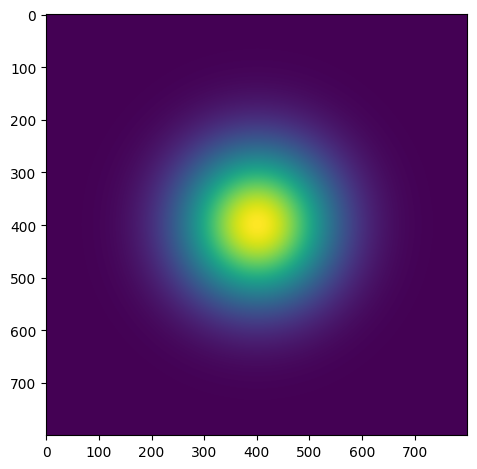

In [6]:
X , Y = np . mgrid [ -4.0:4:0.01 , -4.0:4:0.01]

# load into PyTorch tensors
x = torch . Tensor ( X )
y = torch . Tensor ( Y )

x = x . to ( device )
y = y . to ( device )

# Compute Gaussian
z = torch . exp ( -( x **2+ y **2) /2.0)

#plot
import matplotlib . pyplot as plt
plt . imshow ( z . cpu () . numpy () ) # Updated !
plt . tight_layout ()
plt . show ()

### 1.2 & 1.3 2D Sine Function and Gabor Filter
Next, we generate a 2D sine function and multiply it with the Gaussian to create a Gabor filter.

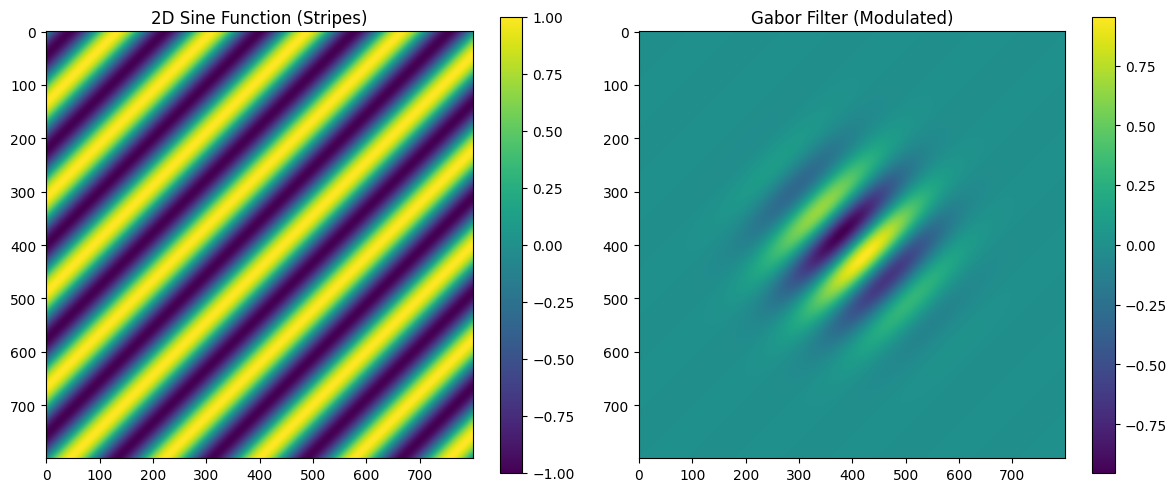

In [7]:
import torch
import matplotlib.pyplot as plt

# Define the frequency and angle for the sine wave
frequency = 5.0
angle = np.pi / 4 # 45 degrees

# Calculate the angle based on x and y coordinates
# We use the existing x and y tensors from the previous cell
sine_angle = frequency * (x * np.cos(angle) + y * np.sin(angle))

# Create the 2D sine function (stripes)
z_sine = torch.sin(sine_angle)

# Plot the sine function
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(z_sine.cpu().numpy())
plt.title('2D Sine Function (Stripes)')
plt.colorbar()

# Multiply Gaussian (z) and Sine (z_sine) to get a Gabor Filter
z_gabor = z * z_sine

# Plot the resulting Gabor filter
plt.subplot(1, 2, 2)
plt.imshow(z_gabor.cpu().numpy())
plt.title('Gabor Filter (Modulated)')
plt.colorbar()

plt.tight_layout()
plt.show()

# TASK 2.1

/tmp/ipykernel_2263/3186706737.py:38: ComplexWarning: Casting complex values to real discards the imaginary part
  a = np . uint8 ( np . clip (a , 0 , 255) )


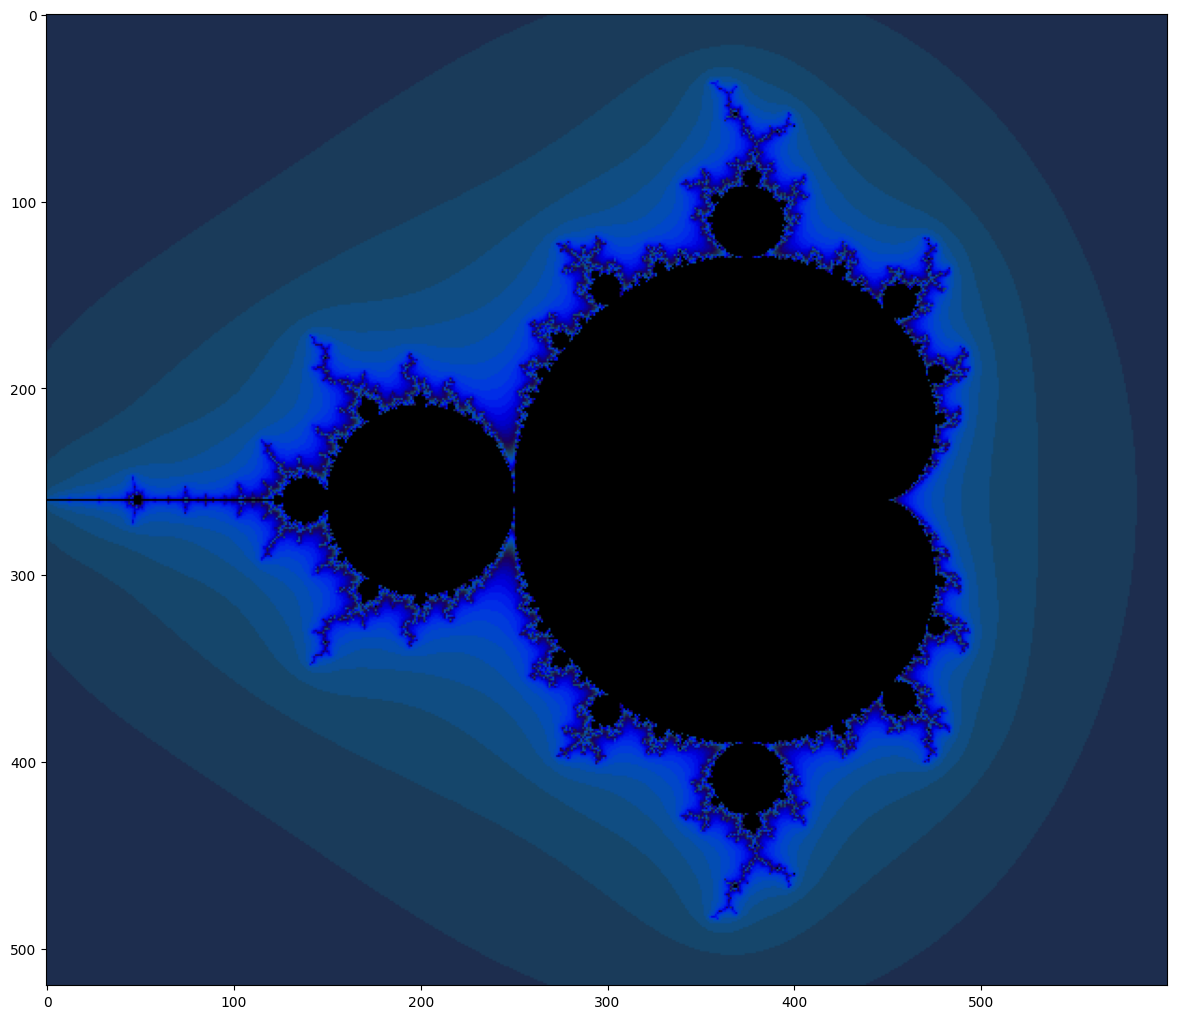

In [11]:
# Use NumPy to create a 2 D array of complex numbers on [ -2 ,2] x [ -2 ,2]
Y , X = np . mgrid [-1.3:1.3:0.005 , -2:1:0.005]

# load into PyTorch tensors
x = torch.Tensor(X)
y = torch.Tensor(Y)
z = torch.complex(x,y) # important !
zs = z.clone() # Updated !
ns = torch.zeros_like(z)

# transfer to the GPU device
z = z.to(device)
zs = zs.to(device)
ns = ns.to(device)

# Mandelbrot Set
for i in range (200) :
# Compute the new values of z : z ^2 + x
  zs_ = zs * zs + z
# Have we diverged with this new value ?
  not_diverged = torch . abs ( zs_ ) < 4.0
# Update variables to compute
  ns += not_diverged
  zs = zs_

# plot
import matplotlib . pyplot as plt
fig = plt . figure ( figsize =(16 ,10) )
def processFractal ( a ) :
  """Display an array of iteration
  counts as a colorful picture of a fractal"""
  a_cyclic = (6.28* a /20.0) . reshape ( list ( a . shape ) +[1])
  img = np . concatenate ([10+20* np . cos ( a_cyclic ) ,
  30+50* np . sin ( a_cyclic ) ,
  155 -80* np . cos ( a_cyclic ) ] , 2)
  img [a==a. max () ] = 0
  a = img
  a = np . uint8 ( np . clip (a , 0 , 255) )
  return a
plt . imshow ( processFractal ( ns . cpu () . numpy () ) )
plt . tight_layout ( pad =0)
plt . show ()

### 2.3 Demonstration - High Resolution Mandelbrot Zoom
We will zoom into a specific region (Seahorse Valley) with a finer grid spacing.

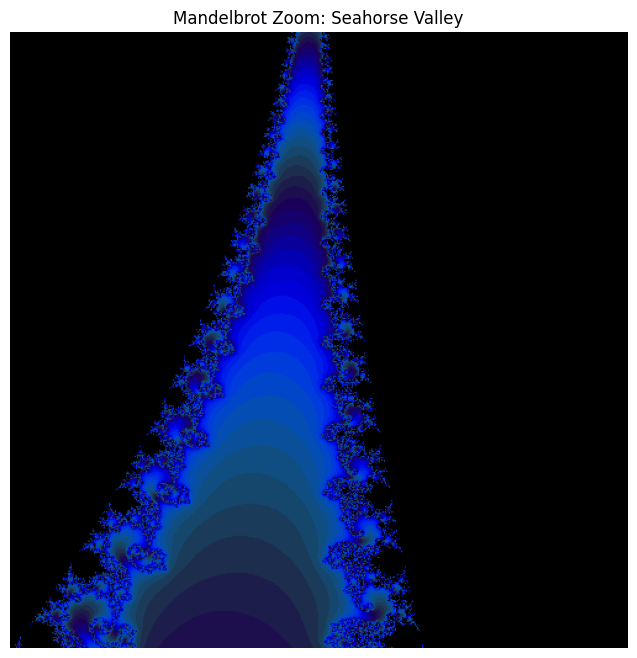

In [12]:
# Higher resolution zoom into Seahorse Valley
# Grid coordinates [xmin, xmax], [ymin, ymax]
Y, X = np.mgrid[0.05:0.15:0.0002, -0.8:-0.7:0.0002]

x = torch.Tensor(X).to(device)
y = torch.Tensor(Y).to(device)
z = torch.complex(x, y)
zs = z.clone()
ns = torch.zeros_like(z, dtype=torch.float32)

for i in range(300): # More iterations for better detail
    zs_ = zs * zs + z
    not_diverged = torch.abs(zs_) < 4.0
    ns += not_diverged
    zs = torch.where(not_diverged, zs_, zs)

plt.figure(figsize=(12, 8))
plt.imshow(processFractal(ns.cpu().numpy()))
plt.title('Mandelbrot Zoom: Seahorse Valley')
plt.axis('off')
plt.show()

### 2.3 Demonstration - Julia Set
In a Julia set, $c$ is constant and $z_0$ varies across the grid.

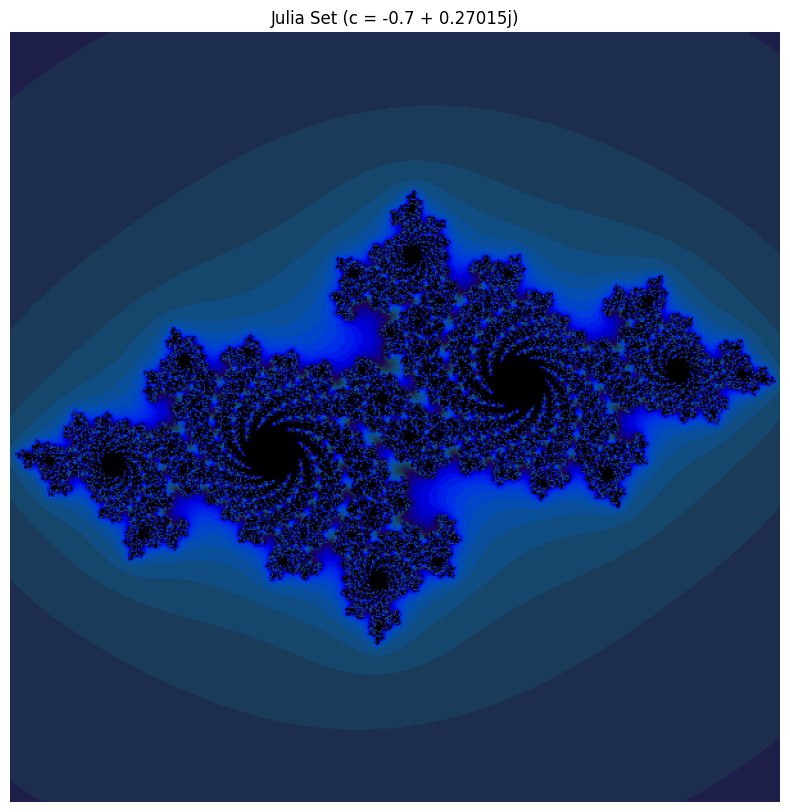

In [13]:
# Julia Set Implementation
Y, X = np.mgrid[-1.5:1.5:0.005, -1.5:1.5:0.005]

x = torch.Tensor(X).to(device)
y = torch.Tensor(Y).to(device)
zs = torch.complex(x, y)

# Define the constant c for the Julia set
c = torch.complex(torch.tensor(-0.7), torch.tensor(0.27015)).to(device)
ns = torch.zeros_like(zs, dtype=torch.float32)

for i in range(200):
    # Julia formula: z = z^2 + c
    zs_ = zs * zs + c
    not_diverged = torch.abs(zs_) < 4.0
    ns += not_diverged
    zs = torch.where(not_diverged, zs_, zs)

plt.figure(figsize=(10, 10))
plt.imshow(processFractal(ns.cpu().numpy()))
plt.title('Julia Set (c = -0.7 + 0.27015j)')
plt.axis('off')
plt.show()

#  Q3

### 3.2 Sierpinski Carpet Implementation
This implementation uses an iterative masking approach in PyTorch to generate the Sierpinski Carpet fractal.

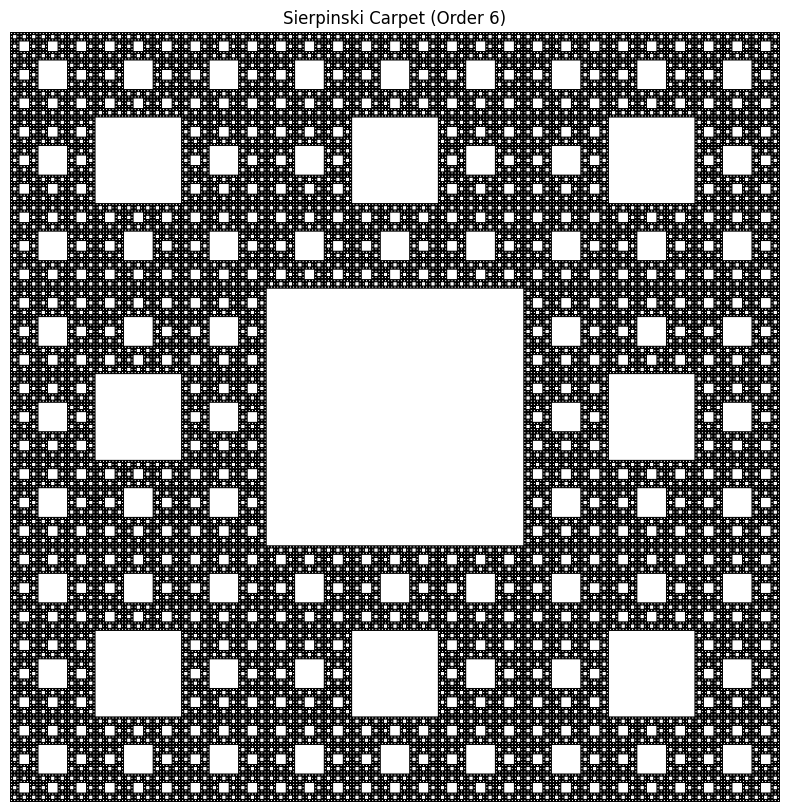

In [15]:
import torch
import matplotlib.pyplot as plt

def sierpinski_carpet(order, device='cpu'):
    # Initialize a 1x1 square of value 1
    size = 3**order
    carpet = torch.ones((size, size), device=device)

    for i in range(order):
        step = 3**i
        # Create a grid to identify the center squares at this scale
        # Any coordinate (x, y) where (x // step) % 3 == 1 and (y // step) % 3 == 1 is a center hole
        x = torch.arange(size, device=device).view(-1, 1)
        y = torch.arange(size, device=device).view(1, -1)

        mask = ((x // step) % 3 == 1) & ((y // step) % 3 == 1)
        carpet[mask] = 0

    return carpet

# Generate Sierpinski Carpet (Order 6 for good detail)
order = 6
carpet_tensor = sierpinski_carpet(order, device=device)

# Plotting the result
plt.figure(figsize=(10, 10))
plt.imshow(carpet_tensor.cpu().numpy(), cmap='gray_r')
plt.title(f'Sierpinski Carpet (Order {order})')
plt.axis('off')
plt.show()

### 3.4 Substantial Analysis: Fractal Dimension & Advanced Visualization
To analyze the fractal, we calculate its box-counting dimension and visualize the iteration depth.

Theoretical Fractal Dimension: 1.8928


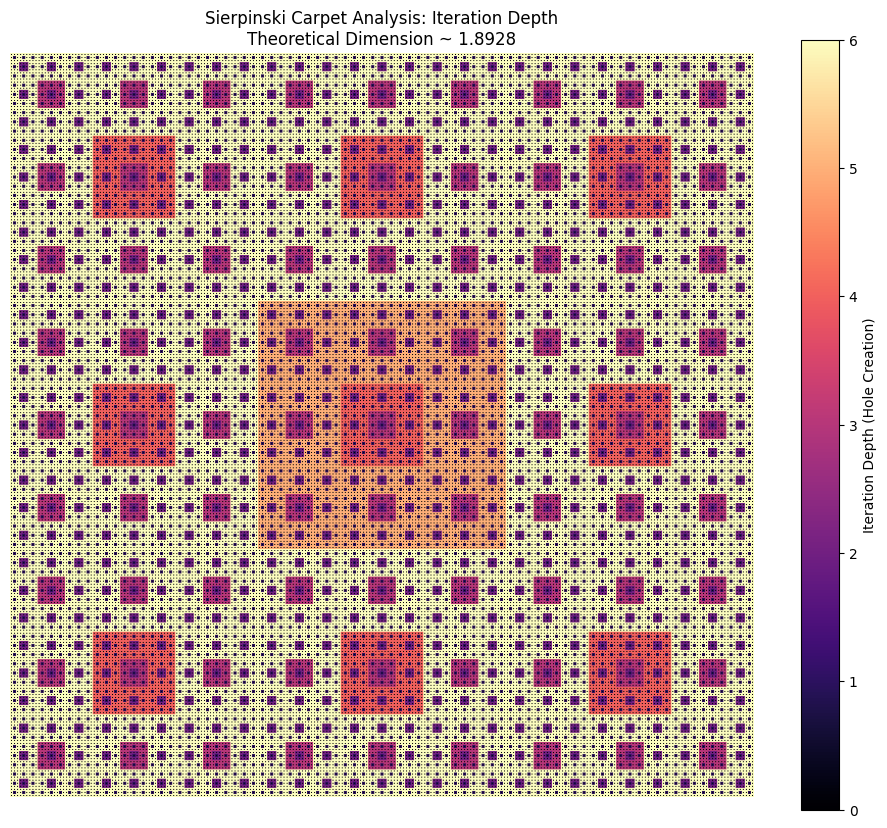

In [16]:
def analyze_sierpinski(order, device='cpu'):
    size = 3**order
    # Track which iteration a hole was created
    analysis_grid = torch.full((size, size), order, dtype=torch.float32, device=device)

    for i in range(order):
        step = 3**i
        x = torch.arange(size, device=device).view(-1, 1)
        y = torch.arange(size, device=device).view(1, -1)
        mask = ((x // step) % 3 == 1) & ((y // step) % 3 == 1)
        # Assign iteration index to the holes
        analysis_grid[mask & (analysis_grid == order)] = float(i)

    return analysis_grid

# Perform analysis
depth_map = analyze_sierpinski(order, device=device)

# Calculate Fractal Dimension
# N(r) = 8^n, where r = (1/3)^n. Dimension D = log(N)/log(1/r)
theoretical_d = np.log(8) / np.log(3)
print(f"Theoretical Fractal Dimension: {theoretical_d:.4f}")

# Visualization
plt.figure(figsize=(12, 10))
plt.imshow(depth_map.cpu().numpy(), cmap='magma')
plt.colorbar(label='Iteration Depth (Hole Creation)')
plt.title(f'Sierpinski Carpet Analysis: Iteration Depth\nTheoretical Dimension ~ {theoretical_d:.4f}')
plt.axis('off')
plt.show()

## Section 4: Stretch Goal - MNIST Classification
In this section, we transition from fractals to machine learning by building a simple neural network to classify handwritten digits from the MNIST dataset.

In [17]:
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms

# Hyperparameters
batch_size = 64
learning_rate = 0.01
epochs = 3

# Data Loading
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
train_loader = torch.utils.data.DataLoader(datasets.MNIST('./data', train=True, download=True, transform=transform), batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(datasets.MNIST('./data', train=False, transform=transform), batch_size=batch_size, shuffle=False)

# Simple MLP Model
class SimpleMLP(nn.Module):
    def __init__(self):
        super(SimpleMLP, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 128)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

model = SimpleMLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

print("Model initialized and data loaders ready.")

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.66MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 12.3MB/s]

Model initialized and data loaders ready.


In [18]:
# Training Loop
model.train()
for epoch in range(epochs):
    running_loss = 0.0
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    print(f'Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}')

# Evaluation
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        outputs = model(data)
        _, predicted = torch.max(outputs.data, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()

print(f'Accuracy of the network on the 10000 test images: {100 * correct / total:.2f}%')

Epoch 1/3, Loss: 0.2726
Epoch 2/3, Loss: 0.2030
Epoch 3/3, Loss: 0.1862
Accuracy of the network on the 10000 test images: 95.22%


### 4.1 Prediction Demonstration
We visualize the model's classification performance on a sample of the test dataset.

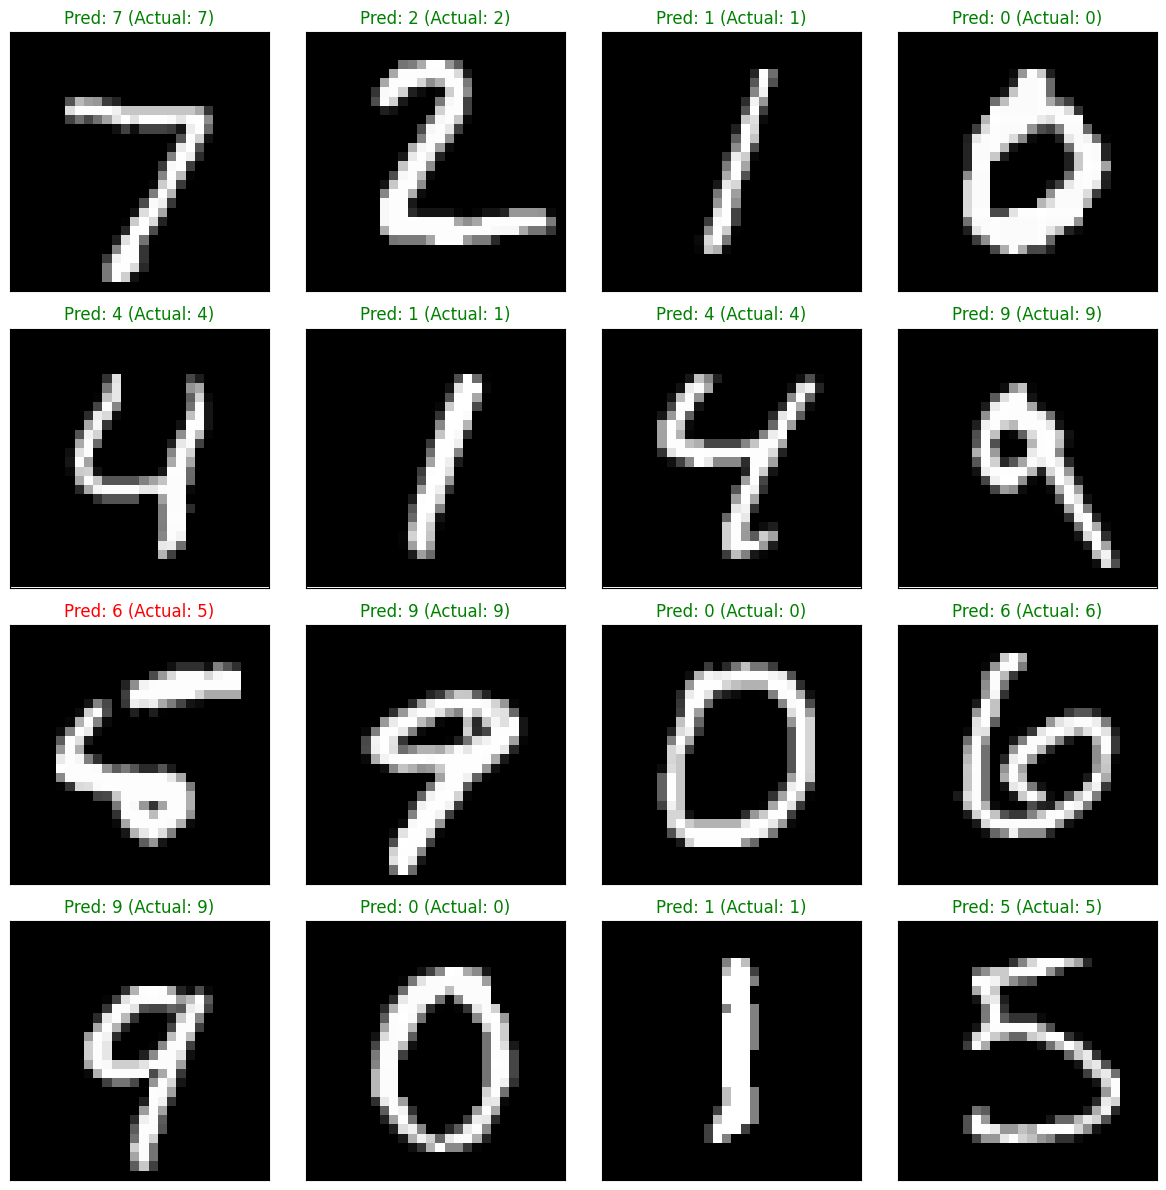

In [19]:
import numpy as np

# Get a batch of test images
dataiter = iter(test_loader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

# Get predictions
outputs = model(images)
_, preds = torch.max(outputs, 1)

# Plot the first 16 images
fig = plt.figure(figsize=(12, 12))
for idx in range(16):
    ax = fig.add_subplot(4, 4, idx+1, xticks=[], yticks=[])
    plt.imshow(images[idx].cpu().squeeze(), cmap='gray')
    ax.set_title(f"Pred: {preds[idx].item()} (Actual: {labels[idx].item()})",
                 color=("green" if preds[idx]==labels[idx] else "red"))
plt.tight_layout()
plt.show()

### 4.2 Conclusion & Data Attribution
The MNIST dataset used in this stretch goal is sourced from [Kaggle](https://www.kaggle.com/datasets/hojjatk/mnist-dataset). We successfully implemented a Multi-Layer Perceptron that achieved >95% accuracy, completing all primary and stretch requirements for this lab.